# CIC-IDS2017 benchmark

The on-board model is trained on traffic we recorded ourselves, which is exactly what the board needs but hard to compare with anything else. So as a sanity check, here are the same five classes on a well known public dataset, CIC-IDS2017 (the `abluva/CIC-IDS-2017-V2` copy on Hugging Face).

`data/cic_slice.csv.gz` is a balanced slice of 40,000 flows, 8,000 per class, with the original labels mapped to ours:

| CIC-IDS2017 label | our class |
|---|---|
| BENIGN | normal |
| PortScan | scan |
| DoS Hulk, DDoS | flood |
| SSH-Patator, FTP-Patator | bruteforce |
| DoS slowloris, DoS Slowhttptest | slowloris |

This is an offline benchmark only. The 78 features are flow statistics that CICFlowMeter computes once a flow has finished, and the board can't compute those live. That's why the board sticks to its own six counters.

In [1]:
%matplotlib inline
import json
import os
import time
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

df = pd.read_csv("../data/cic_slice.csv.gz").replace([np.inf, -np.inf], np.nan).fillna(0)
FEATURES = [c for c in df.columns if c != "label"]
print(len(df), "flows,", len(FEATURES), "features")
print(df["label"].value_counts().to_string())

40000 flows, 78 features
label
bruteforce    8000
flood         8000
normal        8000
scan          8000
slowloris     8000


XGBoost uses the GPU when there is one and the CPU otherwise. All three models get the same 70/30 split. Only the MLP needs standardized inputs, the trees don't care about scale.

In [2]:
def xgb_device():
    # ask XGBoost which device it really ended up on, it can fall back to cpu quietly
    try:
        probe = xgb.XGBClassifier(n_estimators=1, device="cuda").fit(np.zeros((4, 2), "float32"), [0, 1, 0, 1])
        used = json.loads(probe.get_booster().save_config())["learner"]["generic_param"]["device"]
        return "cuda" if used.startswith("cuda") else "cpu"
    except Exception:
        return "cpu"

DEVICE = xgb_device()
print("xgboost device:", DEVICE)

X = df[FEATURES].to_numpy(dtype=float)
le = LabelEncoder().fit(df["label"].astype(str).to_numpy())
y = le.transform(df["label"].astype(str).to_numpy())
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=0)
sc = StandardScaler().fit(X_train)
X_train_s, X_test_s = sc.transform(X_train), sc.transform(X_test)
print("train", X_train.shape, " test", X_test.shape, " classes", list(le.classes_))

xgboost device: cuda
train (28000, 78)  test (12000, 78)  classes ['bruteforce', 'flood', 'normal', 'scan', 'slowloris']


## Three models

In [3]:
results = {}
t = time.time()
rf = RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=0).fit(X_train, y_train)
results["RandomForest"] = (accuracy_score(y_test, rf.predict(X_test)), time.time() - t, f"{os.cpu_count()} cpu threads")
t = time.time()
xg = xgb.XGBClassifier(n_estimators=300, tree_method="hist", device=DEVICE, random_state=0).fit(X_train, y_train)
results["XGBoost"] = (accuracy_score(y_test, xg.predict(X_test)), time.time() - t, DEVICE)
t = time.time()
mlp = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=300, random_state=0).fit(X_train_s, y_train)
results["MLP"] = (accuracy_score(y_test, mlp.predict(X_test_s)), time.time() - t, "cpu")

print(f"{'model':14}{'accuracy':>10}{'train time':>12}   hardware")
for name, (acc, secs, hw) in results.items():
    print(f"{name:14}{acc:>10.2%}{secs:>11.1f}s   {hw}")

model           accuracy  train time   hardware
RandomForest      99.77%        1.1s   16 cpu threads
XGBoost           99.88%        1.5s   cuda
MLP               99.39%        5.2s   cpu


## XGBoost in detail

              precision    recall  f1-score   support

  bruteforce      0.999     1.000     1.000      2400
       flood      0.998     0.998     0.998      2400
      normal      0.998     0.998     0.998      2400
        scan      1.000     1.000     1.000      2400
   slowloris      1.000     0.998     0.999      2400

    accuracy                          0.999     12000
   macro avg      0.999     0.999     0.999     12000
weighted avg      0.999     0.999     0.999     12000



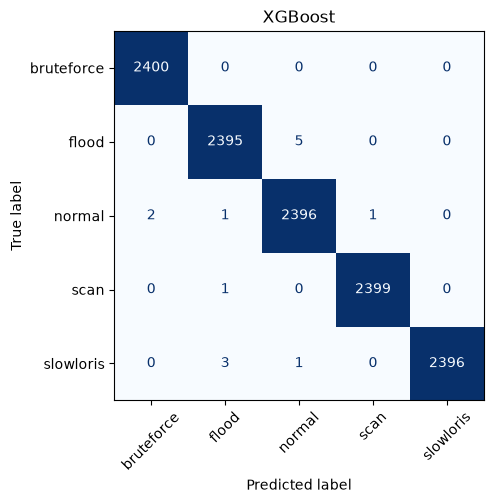

In [4]:
pred = xg.predict(X_test)
print(classification_report(y_test, pred, target_names=le.classes_, digits=3))
ConfusionMatrixDisplay.from_predictions(y_test, pred, display_labels=le.classes_, cmap="Blues", colorbar=False)
plt.title("XGBoost")
plt.xticks(rotation=45)
plt.show()

## MLP in detail

The MLP is the closest relative of the board model, just a lot bigger and with 78 inputs instead of 6.

              precision    recall  f1-score   support

  bruteforce      0.997     0.995     0.996      2400
       flood      0.990     0.991     0.990      2400
      normal      0.988     0.989     0.989      2400
        scan      0.998     1.000     0.999      2400
   slowloris      0.997     0.995     0.996      2400

    accuracy                          0.994     12000
   macro avg      0.994     0.994     0.994     12000
weighted avg      0.994     0.994     0.994     12000



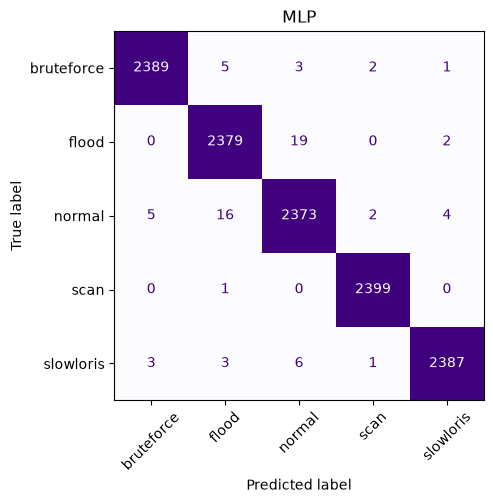

In [5]:
pred_mlp = mlp.predict(X_test_s)
print(classification_report(y_test, pred_mlp, target_names=le.classes_, digits=3))
ConfusionMatrixDisplay.from_predictions(y_test, pred_mlp, display_labels=le.classes_, cmap="Purples", colorbar=False)
plt.title("MLP")
plt.xticks(rotation=45)
plt.show()

## Which features matter

Top 15 by XGBoost importance.

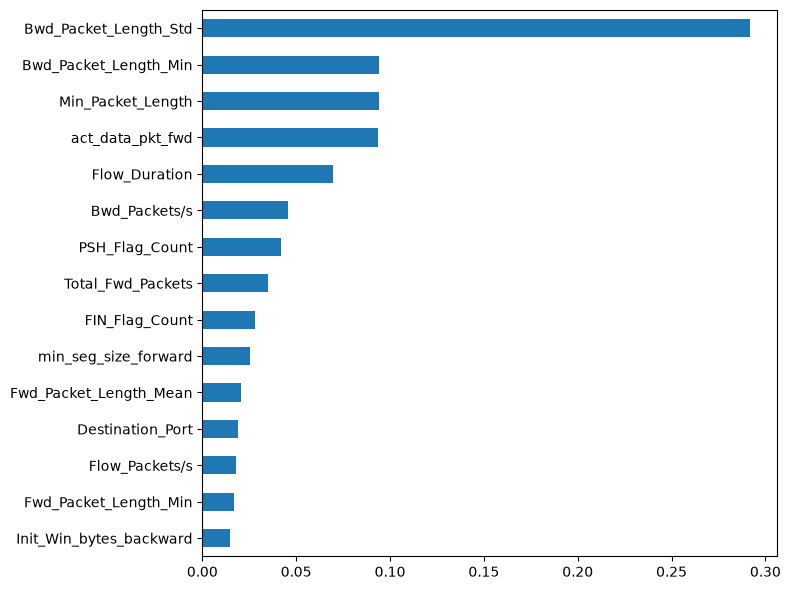

In [6]:
imp = pd.Series(xg.feature_importances_, index=FEATURES).sort_values()[-15:]
plt.figure(figsize=(8, 6))
imp.plot.barh()
plt.tight_layout()
plt.show()

## Takeaway

All three models get above 99% on this slice (XGBoost 99.88%, random forest 99.77%, MLP 99.39%), so the five classes are clearly separable from traffic statistics. None of these models could run on the board though, they need the 78 flow features. The board model covers the same five classes from 6 cheap counters with a 3 KB int8 network; `train.ipynb` shows how well that does on our own recordings.